# Figure 1: Annual Cycle for Classification of Event Types

This notebook generates Figure 1 showing the annual cycle of manually classified aerosol event types. 

## Data Source
Manual classification data from `ZEP_classification.xlsx` in the `Analysis/Classification/` folder.

## Workflow
1. **Load and preprocess**: Read Excel file and apply data quality checks
2. **Analysis**: Extract polar night periods and windblown event statistics
3. **Aggregation**: Resample daily classifications to monthly totals
4. **Visualization**: Create stacked bar chart with event ratio overlay
5. **Export**: Save processed data and generated figure

In [1]:
import pandas as pd
import numpy as np
from matplotlib import colors
import matplotlib.pyplot as plt
from pathlib import Path

## Setup: Import libraries and configure paths

In [2]:
# Define paths relative to notebook location
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
analysis_file_path = project_root / 'Analysis' 
plots_outpath = project_root / 'Plots'

## Load and preprocess data

Load manual classification from Excel file and perform initial quality checks.

In [6]:
classification_file_path = analysis_file_path / 'Classification' / 'ZEP_classification.xlsx'

usecols = ['datetime', 'TE', 'burst', 'less than 50% of data', 'Und',
           'Non Event', 'snow', 'Event', 'comments', 'DMPS class', 'DMPS_count_class_daily',
           'Class Ia', 'Class Ib', 'Class II', 'Undefined', 'Non-event', 'too little data', 
           'maso comments', 'windblown seen in DMPS']

ZEP_class = pd.read_excel(classification_file_path, skiprows=1, usecols=usecols, index_col=0)
ZEP_class = ZEP_class.dropna(how='all')

# Data quality checks
n_valid_days = len(ZEP_class)
burst_percentage = (len(ZEP_class[ZEP_class['burst'] == 1]) * 100 / n_valid_days)
print(f"Valid days: {n_valid_days}")
print(f"Burst events: {burst_percentage:.1f}%")

Valid days: 892
Burst events: 8.2%


In [5]:
# Filter and process classification columns
dalmaso_cols = ['Class Ia', 'Class Ib', 'Class II', 'Undefined', 'Non-event', 
                'too little data', 'maso comments', 'windblown seen in DMPS']
integer_cols = ['Class Ia', 'Class Ib', 'Class II', 'Undefined', 'Non-event', 'too little data']

ZEP_class = ZEP_class[dalmaso_cols].copy()
ZEP_class[integer_cols] = ZEP_class[integer_cols].astype(float)
ZEP_class = ZEP_class.dropna(how='all')

# Add temporal information
ZEP_class['month'] = ZEP_class.index.month
ZEP_class['year'] = ZEP_class.index.year
ZEP_class['month_year'] = (ZEP_class['year'] - 2021) * 12 + ZEP_class['month']

# Identify and report noise events
noise_mask = ZEP_class['maso comments'].str.contains('noise', case=False, na=False)
n_noise_events = noise_mask.sum()
print(f"Noise events identified: {n_noise_events}")

Noise events identified: 2


In [ ]:
#find and select polar nights the dates refer to when the sun rises and sets for the polar day and night
polarnight_stops = '2023-02-17'
polarnight_starts = '2022-10-25'  

polarnight_22_23 = ZEP_class[(polarnight_stops > ZEP_class.index) & (ZEP_class.index > polarnight_starts)]

polarnight_stops_23_24 = '2024-02-17'
polarnight_starts_23_24 = '2023-10-25'          
polarnight_23_24 = ZEP_class[(polarnight_stops_23_24 > ZEP_class.index) & (ZEP_class.index > polarnight_starts_23_24)]

print(polarnight_22_23[['Class Ia','Class Ib','Class II']].dropna(how='all'))
print(polarnight_23_24[['Class Ia','Class Ib','Class II']].dropna(how='all'))

            Class Ia  Class Ib  Class II
datetime                                
2022-11-25       NaN       NaN       1.0
            Class Ia  Class Ib  Class II
datetime                                
2023-10-28       NaN       NaN       1.0
2023-11-01       NaN       NaN       1.0
2023-11-02       NaN       NaN       1.0
2023-11-03       NaN       NaN       1.0


## Analysis: Polar night and windblown events

In [ ]:
# Analyze windblown events seen in DMPS data
windblown_col = 'windblown seen in DMPS'
windblown_data = ZEP_class[windblown_col].dropna()

n_windblown_total = len(windblown_data)
n_no_clouds = (windblown_data == 'no/opposite clouds?').sum()
n_no_snow = (windblown_data == 'n/a no snow').sum()
n_yes = (windblown_data == 'yes').sum()
n_yes_maybe = (windblown_data == 'yes?').sum()

# Calculate ratio of confirmed/probable windblown events
n_valid_windblown = n_windblown_total - n_no_clouds - n_no_snow
ratio_windblown = (n_yes + n_yes_maybe) / n_valid_windblown if n_valid_windblown > 0 else 0

print(f"Windblown events (DMPS confirmed): {n_windblown_total}")
print(f"  - Yes: {n_yes}, Yes maybe: {n_yes_maybe}")
print(f"  - No clouds: {n_no_clouds}, No snow: {n_no_snow}")
print(f"Confirmed/probable ratio: {ratio_windblown:.2%}")

Windblown events (DMPS confirmed): 94
  - Yes: 36, Yes maybe: 1
  - No clouds: 3, No snow: 1
Confirmed/probable ratio: 41.11%


In [ ]:
def resample_monthly_sum(df, columns):
    """
    Resample daily data to monthly sums.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with daily data indexed by datetime
    columns : list
        Column names to sum
        
    Returns
    -------
    pd.DataFrame
        Monthly aggregated data with index as 'YYYY-MM' strings
    """
    df_monthly = df[columns].resample('ME').sum()
    df_monthly.index = pd.to_datetime(df_monthly.index).strftime('%Y-%m')
    return df_monthly

## Visualization: Prepare monthly aggregation and plotting functions

In [ ]:
ZEP_class_monthly = resample_monthly_sum(ZEP_class, integer_cols)

In [ ]:
ZEP_class_monthly.head(2)

,Class Ia,Class Ib,Class II,Undefined,Non-event,too little data
datetime,,,,,,
2022-04,2.0,0.0,4.0,6.0,1.0,1.0
2022-05,2.0,1.0,7.0,12.0,9.0,0.0


In [ ]:
# Save processed classification data
output_file = project_root / 'Analysis' / 'Classification' / 'ZEP_class_DalMaso.txt'
ZEP_class.to_csv(output_file)
print(f"Saved to: {output_file}")

Saved to: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\Classification\ZEP_class_DalMaso.txt


In [ ]:
def make_stacked_barchart(df, resampled_df, cols=None, fontsize=20):
    """
    Create a stacked bar chart of event classifications with normalized event ratio overlay.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with monthly aggregated data (index as 'YYYY-MM')
    resampled_df : pd.DataFrame
        DataFrame with 'event_norm' column for overlay
    cols : list, optional
        Column names to plot. Defaults to ['Class Ia', 'Class Ib', 'Class II', 'Undefined', 'Non-event']
    fontsize : int, optional
        Font size for labels (default: 20)
        
    Returns
    -------
    matplotlib.figure.Figure
        The figure object
    """
    if cols is None:
        cols = ['Class Ia', 'Class Ib', 'Class II', 'Undefined', 'Non-event']
    
    df_plot = df[cols].copy()
    df_plot['index'] = df.index
    
    # Set up colors with varying alphas
    colors_list = ['red', 'orange', 'yellow', 'green', 'gray']
    rgba_colors = np.array([list(colors.to_rgba(x)) for x in colors_list])
    alphas = np.linspace(1, 0.2, len(cols))
    rgba_colors[:, 3] = alphas
    
    # Create stacked bar chart
    ax = df_plot.plot(x='index', y=cols, kind='bar', stacked=True, figsize=(12, 5), 
                      color=rgba_colors)
    ax.set_title("", color='black')
    ax.legend(frameon=False, bbox_to_anchor=(0.055, 1.01), fontsize=15, ncol=5)
    
    # Format x-axis with month abbreviations
    month_abbrev = {1: 'J', 2: 'F', 3: 'M', 4: 'A', 5: 'M', 6: 'J', 
                    7: 'J', 8: 'A', 9: 'S', 10: 'O', 11: 'N', 12: 'D'}
    months = [int(x[-2:]) for x in df.index]
    letters = [month_abbrev[m] for m in months]
    ax.set_xticklabels(letters)
    
    # Styling
    ax.set_xlabel('', fontsize=fontsize)
    ax.set_ylabel('Number of days [-]', fontsize=fontsize)
    ax.tick_params(labelsize=fontsize, axis='both', which='major')
    
    # Overlay event ratio on secondary axis
    ax2 = ax.twinx()
    ax2.plot(resampled_df.index, resampled_df['event_norm'], 'o-', c='k', alpha=0.5, linewidth=2)
    ax2.set_ylabel('Event/Total [-]', fontsize=fontsize)
    ax2.tick_params(labelsize=fontsize, axis='both', which='major')
    
    # Spine styling
    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_linewidth(2)
        ax2.spines[spine].set_linewidth(2)
    
    # Add year annotations
    fig = ax.get_figure()
    ax.annotate('2022', (0.043, -0.15), xycoords='axes fraction', fontsize=fontsize)
    ax.annotate('2023', (0.43, -0.15), xycoords='axes fraction', fontsize=fontsize)
    ax.annotate('2024', (0.815, -0.15), xycoords='axes fraction', fontsize=fontsize)
    
    plt.xticks(fontsize=fontsize, rotation='horizontal')
    
    return fig


def save_plot(fig, filepath, dpi=300):
    """
    Save figure to file with automatic directory creation.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    filepath : str or Path
        Full path where to save the figure (e.g., 'path/to/figure.jpeg')
    dpi : int, optional
        Resolution in dots per inch (default: 300)
    """
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    print(f"Saved: {filepath}")

In [ ]:
# Calculate total counts by classification
print("Classification totals across all months:")
print("-" * 40)
class_totals = {}
for col in ZEP_class_monthly.columns[:-3]:  # Exclude 'event', 'total', 'event_norm'
    col_sum = ZEP_class_monthly[col].sum()
    class_totals[col] = col_sum
    print(f"{col:20s}: {col_sum:6.0f} days")

print("-" * 40)
print(f"{'Total':20s}: {sum(class_totals.values()):6.0f} days")

Classification totals across all months:
----------------------------------------
Class Ia            :     27 days
Class Ib            :     19 days
Class II            :    109 days
----------------------------------------
Total               :    155 days


## Summary statistics and figure generation

In [ ]:
ZEP_class_monthly['event'] = ZEP_class_monthly[['Class Ia', 'Class Ib', 'Class II']].sum(axis=1)
ZEP_class_monthly['total'] = ZEP_class_monthly[['Class Ia', 'Class Ib', 'Class II', 'Undefined', 'Non-event']].sum(axis=1)
ZEP_class_monthly['event_norm'] = ZEP_class_monthly['event']/ZEP_class_monthly['total']

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_1.jpeg


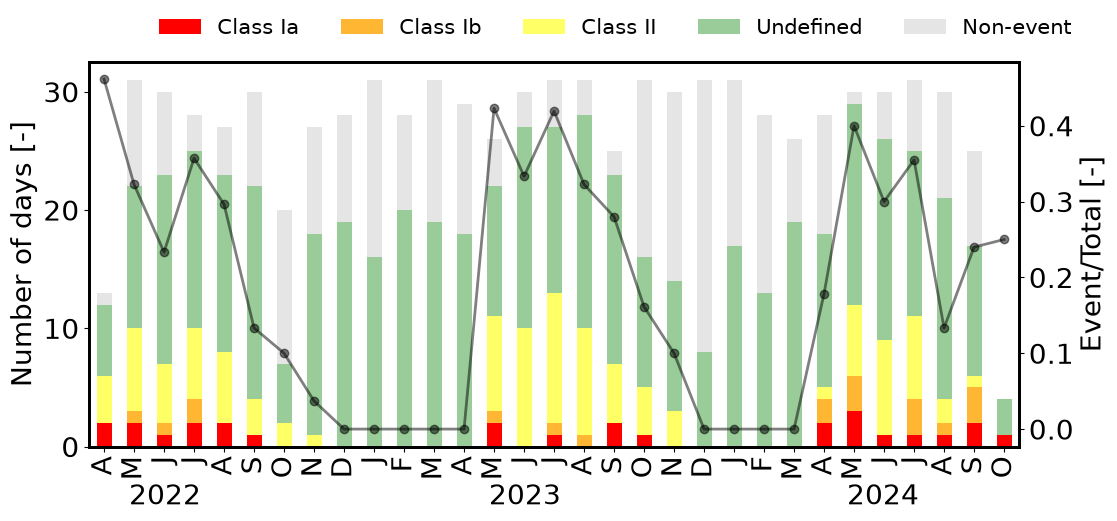

In [ ]:
# Generate and save figure
fig = make_stacked_barchart(ZEP_class_monthly, ZEP_class_monthly)
output_figure = plots_outpath / 'Figure_1.jpeg'
save_plot(fig, output_figure)